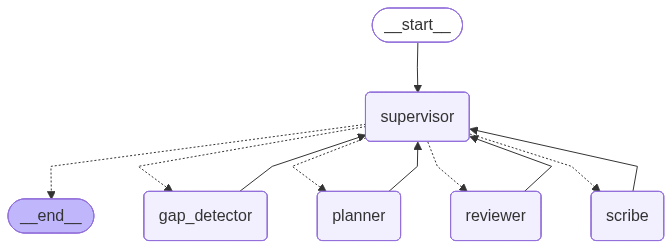

Running clinical documentation & follow-up agent...


[DEBUG] Supervisor sees:
SOAP: False
Gaps: []
Plan: False
Final: False
[DEBUG] Supervisor decision: scribe
[scribe] S: Patient reports feeling tired, thirsty, and experiencing increased urination, with an 8 lb weight loss over the past 3 months. Family history of type 2 diabetes, with mother bei...

[DEBUG] Supervisor sees:
SOAP: True
Gaps: []
Plan: False
Final: False
[DEBUG] invalid LLM decision '', forcing 'gap_detector' based on state
[DEBUG] Supervisor decision: gap_detector
[scribe] S: Patient reports feeling tired, thirsty, and experiencing increased urination, with an 8 lb weight loss over the past 3 months. Family history of type 2 diabetes, with mother bei...
[gap_detector] Based on the provided information and assuming standard clinical guidelines for diabetes screening and management, the following gaps or needs are identified:
* No explicit denial ...

[DEBUG] Supervisor sees:
SOAP: True
Gaps: ['* No explicit denial of b

In [2]:
import os
from typing import Annotated, Sequence, TypedDict, Literal
from datetime import datetime

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# ────────────────────────────────────────────────
#  CONFIG
# ────────────────────────────────────────────────
load_dotenv()

SUPERVISOR_MODEL = "llama-3.1-8b-instant"          # keep fast & cheap for routing
AGENT_MODEL = "llama-3.3-70b-versatile"            # stronger reasoning for content generation


def get_chat_model():
    return ChatGroq(
        model=AGENT_MODEL,
        temperature=0.1,
        max_tokens=2048,
    )

def get_supervisor_model():
    return ChatGroq(
        model=SUPERVISOR_MODEL,
        temperature=0.0,  # deterministic for routing
        max_tokens=512,
    )

llm = get_chat_model()
supervisor_llm = get_supervisor_model()

# Mock retriever (unchanged)
def mock_guidelines_retriever(query: str) -> str:
    if "diabetes" in query.lower():
        return "ADA 2025: Annual eye exam, A1c <7%, foot exam q visit, statin if >40yo"
    return "No specific guideline match found."

# ────────────────────────────────────────────────
#  STATE
# ────────────────────────────────────────────────
class ClinicalState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], "add_messages"]
    transcript: str
    soap_note: str | None
    care_gaps: list[str]
    follow_up_plan: str | None
    final_report: str | None
    next: Literal["scribe", "gap_detector", "planner", "reviewer", "__end__"] | None

# ────────────────────────────────────────────────
#  AGENT NODES – now return structured updates
# ────────────────────────────────────────────────

def create_agent_node(name: str, system_prompt: str, state_key: str | None = None, parser_func=None):
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder("messages"),
    ])
    chain = prompt | llm

    def node(state: ClinicalState, config: RunnableConfig):
        response = chain.invoke({
            "messages": state["messages"],
            "transcript": state.get("transcript", ""),
            "soap_note": state.get("soap_note", ""),
            "care_gaps": state.get("care_gaps", []),
            "follow_up_plan": state.get("follow_up_plan", ""),
        })
        content = response.content.strip()
        update = {
            "messages": [AIMessage(content=content, name=name)],
        }
        if state_key and parser_func:
            parsed = parser_func(content)
            update[state_key] = parsed
        elif state_key:
            update[state_key] = content  # fallback
        return update

    node.__name__ = name
    return node

# Simple parsers
def parse_soap(content: str) -> str | None:
    if "S:" in content and "O:" in content:
        return content
    return None  # or raise/log error

def parse_gaps(content: str) -> list[str]:
    lines = [line.strip() for line in content.split("\n") if line.strip().startswith(("-", "*"))]
    return lines if lines else ["No gaps identified"]

def parse_plan(content: str) -> str | None:
    if "Follow-up Actions:" in content and "Patient Message:" in content:
        return content
    return None

scribe_agent = create_agent_node(
    "scribe",
    """You are an expert medical scribe. Convert the raw conversation transcript into a clean, structured SOAP note.
Use standard format:
S: Subjective
O: Objective
A: Assessment
P: Plan

Be concise, professional, accurate. Do NOT diagnose or invent information.
Output ONLY the SOAP note.""",
    state_key="soap_note",
    parser_func=parse_soap
)

gap_detector_agent = create_agent_node(
    "gap_detector",
    """You are a clinical quality agent. Review the SOAP note and transcript.
Identify care gaps, missed screenings, guideline non-adherence, or follow-up needs.
Use provided mock guidelines if relevant.
Return a bullet list of gaps or "No gaps identified".""",
    state_key="care_gaps",
    parser_func=parse_gaps
)

planner_agent = create_agent_node(
    "planner",
    """You are a care coordinator. Based on SOAP and care gaps:
1. Suggest concrete follow-up actions (tests, referrals, meds, education)
2. Draft a short, patient-friendly message summarizing key points and next steps
Output format:
Follow-up Actions: ...
Patient Message: Dear [Patient], ...""",
    state_key="follow_up_plan",
    parser_func=parse_plan
)

reviewer_agent = create_agent_node(
    "reviewer",
    """You are the final clinical reviewer (simulating physician review).
Read entire state. Check for:
- Accuracy
- Completeness
- Safety (no hallucinated diagnoses)
- Clarity

If acceptable, output: APPROVED\nFINAL REPORT:\n[assembled output here]
If issues, output: ISSUES FOUND\n[explanation]""",
    state_key="final_report",  # reviewer now directly sets final_report if approved
    parser_func=lambda c: c if "APPROVED" in c else None
)

# ────────────────────────────────────────────────
#  SUPERVISOR (router) – strengthened
# ────────────────────────────────────────────────
supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a strict workflow supervisor. Your ONLY job is to choose the next step based on these EXACT rules. Do NOT think creatively. Do NOT add explanations.

Current state flags:
SOAP exists: {has_soap} (True/False)
Gaps exist: {has_gaps} (True if list has items beyond "No gaps identified", False otherwise)
Plan exists: {has_plan} (True/False)
Final report exists: {has_report} (True/False)

Routing rules — follow in this order:
1. If SOAP exists is False → MUST return "scribe"
2. If SOAP exists is True AND Gaps exist is False → MUST return "gap_detector"
3. If Gaps exist is True → MUST return "planner"   # always planner when there are gaps
4. If Plan exists is True AND Final report exists is False → MUST return "reviewer"
5. If Final report exists is True → MUST return "__end__"

Examples:
- SOAP: False, others False → "scribe"
- SOAP: True, Gaps: [], Plan: False, Final: False → "gap_detector"
- SOAP: True, Gaps: ["- missing A1c"], Plan: False → "planner"
- SOAP: True, Gaps: ["- gap"], Plan: True, Final: False → "reviewer"    # this case now handled

Respond with EXACTLY ONE of these words and NOTHING ELSE: scribe gap_detector planner reviewer __end__"""),
    MessagesPlaceholder("messages"),
])

supervisor_chain = supervisor_prompt | supervisor_llm

def supervisor_node(state: ClinicalState):
    # Debug print (remove later)
    print("\n[DEBUG] Supervisor sees:")
    print(f"SOAP: {bool(state.get('soap_note'))}")
    print(f"Gaps: {state.get('care_gaps')}")
    print(f"Plan: {bool(state.get('follow_up_plan'))}")
    print(f"Final: {bool(state.get('final_report'))}")

    has_soap = bool(state.get("soap_note"))
    gaps_list = state.get("care_gaps", []) or []
    # treat only meaningful gap items as indicating a gap; ignore placeholder
    has_gaps = any(g and g.lower() != "no gaps identified" for g in gaps_list)
    has_plan = bool(state.get("follow_up_plan"))
    has_report = bool(state.get("final_report"))

    resp = supervisor_chain.invoke({
        "messages": state["messages"][-6:],
        "has_soap": has_soap,
        "has_gaps": has_gaps,
        "has_plan": has_plan,
        "has_report": has_report,
    })
    raw = resp.content.strip().lower()
    valid = ["scribe", "gap_detector", "planner", "reviewer", "__end__"]
    if raw in valid:
        decision = raw
    else:
        # fallback deterministic routing based on state flags
        if not has_soap:
            decision = "scribe"
        elif not has_gaps:
            decision = "gap_detector"
        elif not has_plan:
            decision = "planner"
        else:
            decision = "reviewer"
        print(f"[DEBUG] invalid LLM decision '{raw}', forcing '{decision}' based on state")

    print(f"[DEBUG] Supervisor decision: {decision}")
    return {"next": decision}

# ────────────────────────────────────────────────
#  GRAPH
# ────────────────────────────────────────────────
workflow = StateGraph(state_schema=ClinicalState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("scribe", scribe_agent)
workflow.add_node("gap_detector", gap_detector_agent)
workflow.add_node("planner", planner_agent)
workflow.add_node("reviewer", reviewer_agent)

for node in ["scribe", "gap_detector", "planner", "reviewer"]:
    workflow.add_edge(node, "supervisor")

def route_supervisor(state: ClinicalState) -> str:
    next_step = state.get("next", "__end__")
    return next_step if next_step != "__end__" else END

workflow.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {"scribe": "scribe", "gap_detector": "gap_detector", "planner": "planner", "reviewer": "reviewer", END: END}
)

workflow.add_edge(START, "supervisor")



# Safety: max 20 steps to prevent accidental loops
checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

# ────────────────────────────────────────────────
#  RUN EXAMPLE (unchanged)
# ────────────────────────────────────────────────
if __name__ == "__main__":
    config = {"configurable": {"thread_id": "demo_session_1"}}

    initial_transcript = """
    Patient: I've been feeling tired, thirsty a lot, peeing more. Weight down 8 lb last 3 months.
    Doctor: Any family history diabetes? Blurry vision? Numbness feet?
    Patient: Mom had type 2. No numbness yet.
    Doctor: BP 138/84, weight 210 lb, height 5'10". I'll order A1c, lipid panel, urine microalb.
    """

    initial_state = {
        "messages": [HumanMessage(content=f"New consultation transcript:\n{initial_transcript}")],
        "transcript": initial_transcript,
        "care_gaps": [],  # initialize empty list
    }

    print("Running clinical documentation & follow-up agent...\n")

    for event in graph.stream(initial_state, config, stream_mode="values"):
        last_msg = event["messages"][-1]
        if isinstance(last_msg, AIMessage):
            name = last_msg.name or "Agent"
            print(f"[{name}] {last_msg.content[:180]}{'...' if len(last_msg.content)>180 else ''}")
        
        if "final_report" in event and event["final_report"]:
            print("\n" + "="*70)
            print("FINAL CLINICAL REPORT")
            print("="*70)
            print(event["final_report"])
            break